Plotting Loss

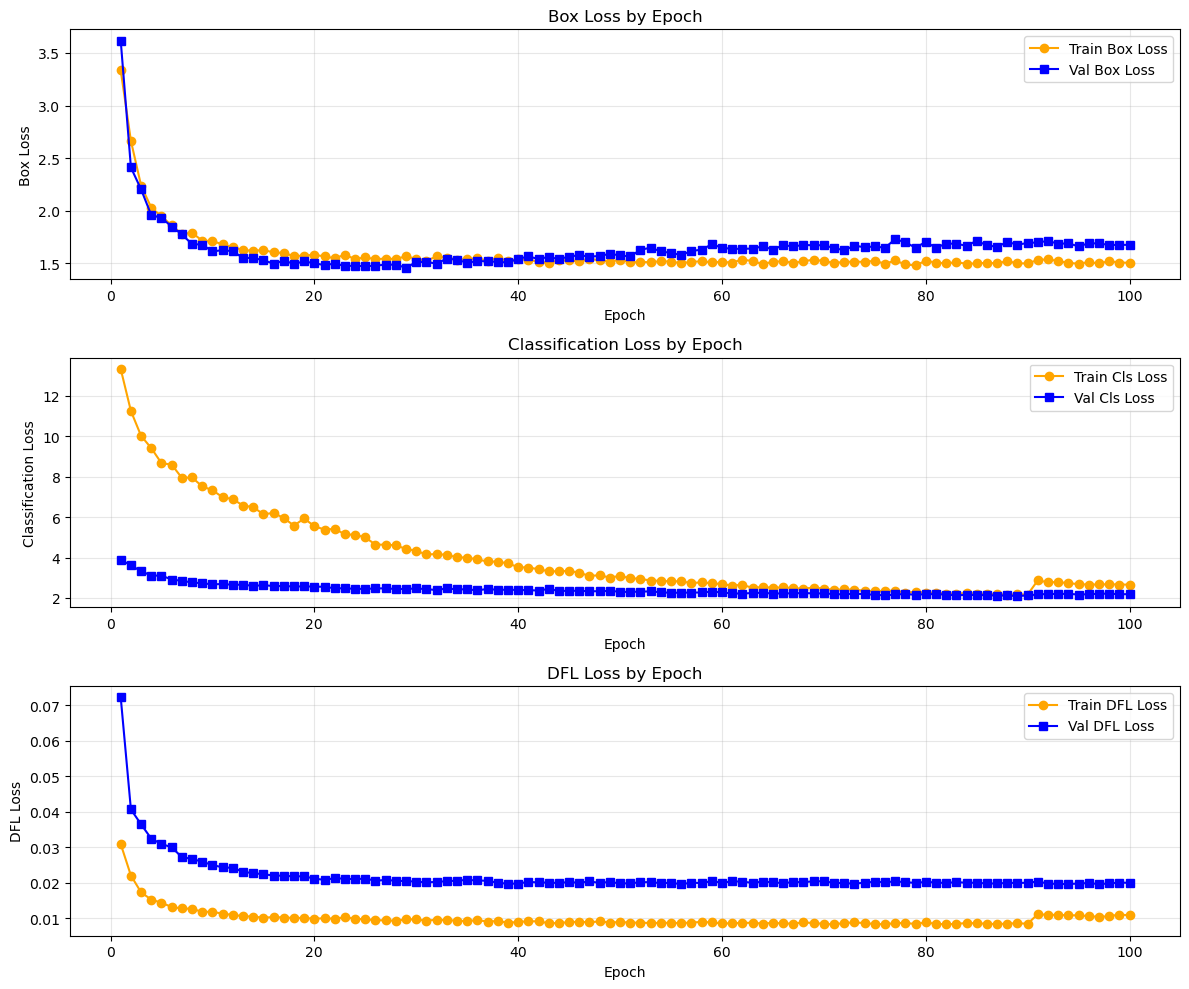

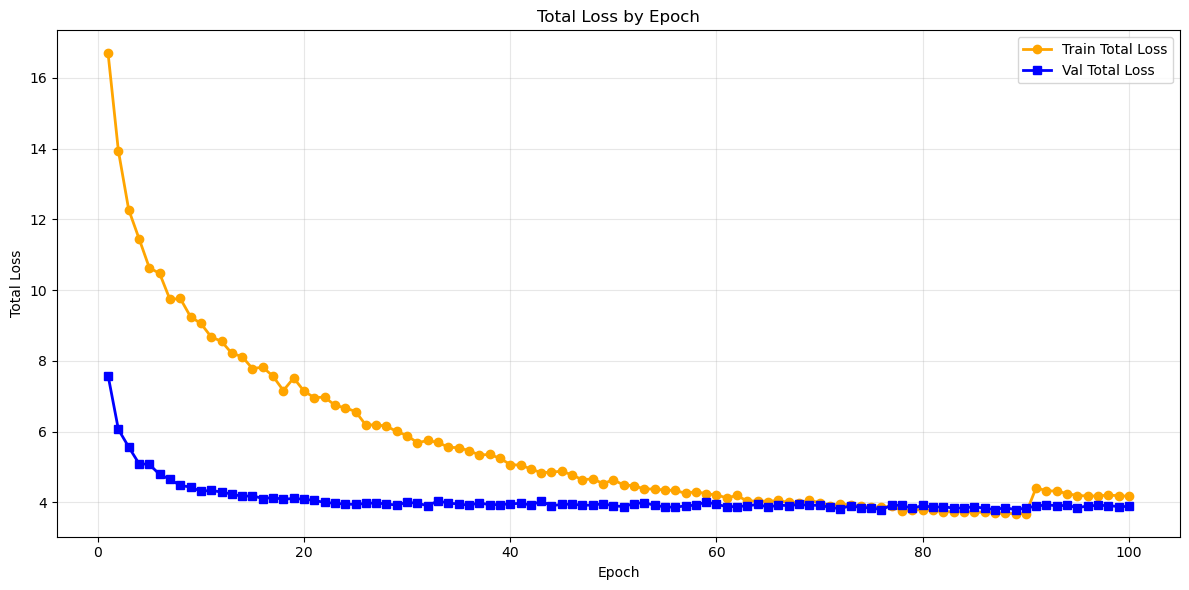

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Configure matplotlib for notebook
%matplotlib inline

# Load the results CSV
df = pd.read_csv('/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/YOLO/runs/detect/train4/results.csv')

# Create figure with subplots for different loss types
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot box loss
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', marker='o', color='orange')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', marker='s', color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Box Loss')
axes[0].set_title('Box Loss by Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot classification loss
axes[1].plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss', marker='o', color='orange')
axes[1].plot(df['epoch'], df['val/cls_loss'], label='Val Cls Loss', marker='s', color='blue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Classification Loss')
axes[1].set_title('Classification Loss by Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot DFL loss
axes[2].plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss', marker='o', color='orange')
axes[2].plot(df['epoch'], df['val/dfl_loss'], label='Val DFL Loss', marker='s', color='blue')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('DFL Loss')
axes[2].set_title('DFL Loss by Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

# Also create a combined total loss plot
fig2, ax = plt.subplots(figsize=(12, 6))

# Calculate total loss (sum of all three loss components)
df['train/total_loss'] = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
df['val/total_loss'] = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']

ax.plot(df['epoch'], df['train/total_loss'], label='Train Total Loss', marker='o', linewidth=2, color='orange')
ax.plot(df['epoch'], df['val/total_loss'], label='Val Total Loss', marker='s', linewidth=2, color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Total Loss')
ax.set_title('Total Loss by Epoch')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

Training summary and metrics

In [3]:
# Cell 1: Overall Training Summary and Final Metrics
import pandas as pd
import numpy as np

# Load results
results_path = '/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/YOLO/runs/detect/train4'
df = pd.read_csv(f'{results_path}/results.csv')

print("=" * 60)
print("YOLO MODEL TRAINING SUMMARY")
print("=" * 60)
print(f"\nTotal Epochs Trained: {len(df)}")
print(f"Total Training Time: {df['time'].iloc[-1] / 60:.2f} minutes ({df['time'].iloc[-1] / 3600:.2f} hours)")
print(f"Average Time per Epoch: {df['time'].diff().mean():.2f} seconds")

print("\n" + "=" * 60)
print("FINAL MODEL PERFORMANCE (Epoch {})".format(len(df)))
print("=" * 60)
print(f"Precision:    {df['metrics/precision(B)'].iloc[-1]:.4f} ({df['metrics/precision(B)'].iloc[-1]*100:.2f}%)")
print(f"Recall:       {df['metrics/recall(B)'].iloc[-1]:.4f} ({df['metrics/recall(B)'].iloc[-1]*100:.2f}%)")
print(f"mAP@0.5:      {df['metrics/mAP50(B)'].iloc[-1]:.4f} ({df['metrics/mAP50(B)'].iloc[-1]*100:.2f}%)")
print(f"mAP@0.5-0.95: {df['metrics/mAP50-95(B)'].iloc[-1]:.4f} ({df['metrics/mAP50-95(B)'].iloc[-1]*100:.2f}%)")

# Calculate F1 score
precision = df['metrics/precision(B)'].iloc[-1]
recall = df['metrics/recall(B)'].iloc[-1]
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"F1 Score:     {f1_score:.4f} ({f1_score*100:.2f}%)")

print("\n" + "=" * 60)
print("BEST PERFORMANCE DURING TRAINING")
print("=" * 60)
best_map50_idx = df['metrics/mAP50(B)'].idxmax()
print(f"\nBest mAP@0.5: {df['metrics/mAP50(B)'].iloc[best_map50_idx]:.4f} at epoch {best_map50_idx + 1}")
print(f"  Precision: {df['metrics/precision(B)'].iloc[best_map50_idx]:.4f}")
print(f"  Recall:    {df['metrics/recall(B)'].iloc[best_map50_idx]:.4f}")

best_map5095_idx = df['metrics/mAP50-95(B)'].idxmax()
print(f"\nBest mAP@0.5-0.95: {df['metrics/mAP50-95(B)'].iloc[best_map5095_idx]:.4f} at epoch {best_map5095_idx + 1}")
print(f"  Precision: {df['metrics/precision(B)'].iloc[best_map5095_idx]:.4f}")
print(f"  Recall:    {df['metrics/recall(B)'].iloc[best_map5095_idx]:.4f}")

print("\n" + "=" * 60)
print("FINAL LOSS VALUES")
print("=" * 60)
print(f"Training Losses:")
print(f"  Box Loss:      {df['train/box_loss'].iloc[-1]:.4f}")
print(f"  Class Loss:    {df['train/cls_loss'].iloc[-1]:.4f}")
print(f"  DFL Loss:      {df['train/dfl_loss'].iloc[-1]:.4f}")
print(f"  Total:         {df['train/box_loss'].iloc[-1] + df['train/cls_loss'].iloc[-1] + df['train/dfl_loss'].iloc[-1]:.4f}")

print(f"\nValidation Losses:")
print(f"  Box Loss:      {df['val/box_loss'].iloc[-1]:.4f}")
print(f"  Class Loss:    {df['val/cls_loss'].iloc[-1]:.4f}")
print(f"  DFL Loss:      {df['val/dfl_loss'].iloc[-1]:.4f}")
print(f"  Total:         {df['val/box_loss'].iloc[-1] + df['val/cls_loss'].iloc[-1] + df['val/dfl_loss'].iloc[-1]:.4f}")

YOLO MODEL TRAINING SUMMARY

Total Epochs Trained: 100
Total Training Time: 34.06 minutes (0.57 hours)
Average Time per Epoch: 20.19 seconds

FINAL MODEL PERFORMANCE (Epoch 100)
Precision:    0.1837 (18.38%)
Recall:       0.2393 (23.93%)
mAP@0.5:      0.1775 (17.75%)
mAP@0.5-0.95: 0.0933 (9.33%)
F1 Score:     0.2079 (20.79%)

BEST PERFORMANCE DURING TRAINING

Best mAP@0.5: 0.1878 at epoch 76
  Precision: 0.3489
  Recall:    0.1740

Best mAP@0.5-0.95: 0.0963 at epoch 90
  Precision: 0.2482
  Recall:    0.2289

FINAL LOSS VALUES
Training Losses:
  Box Loss:      1.5072
  Class Loss:    2.6583
  DFL Loss:      0.0108
  Total:         4.1763

Validation Losses:
  Box Loss:      1.6771
  Class Loss:    2.1866
  DFL Loss:      0.0199
  Total:         3.8837


Precision/Recall, F1 score

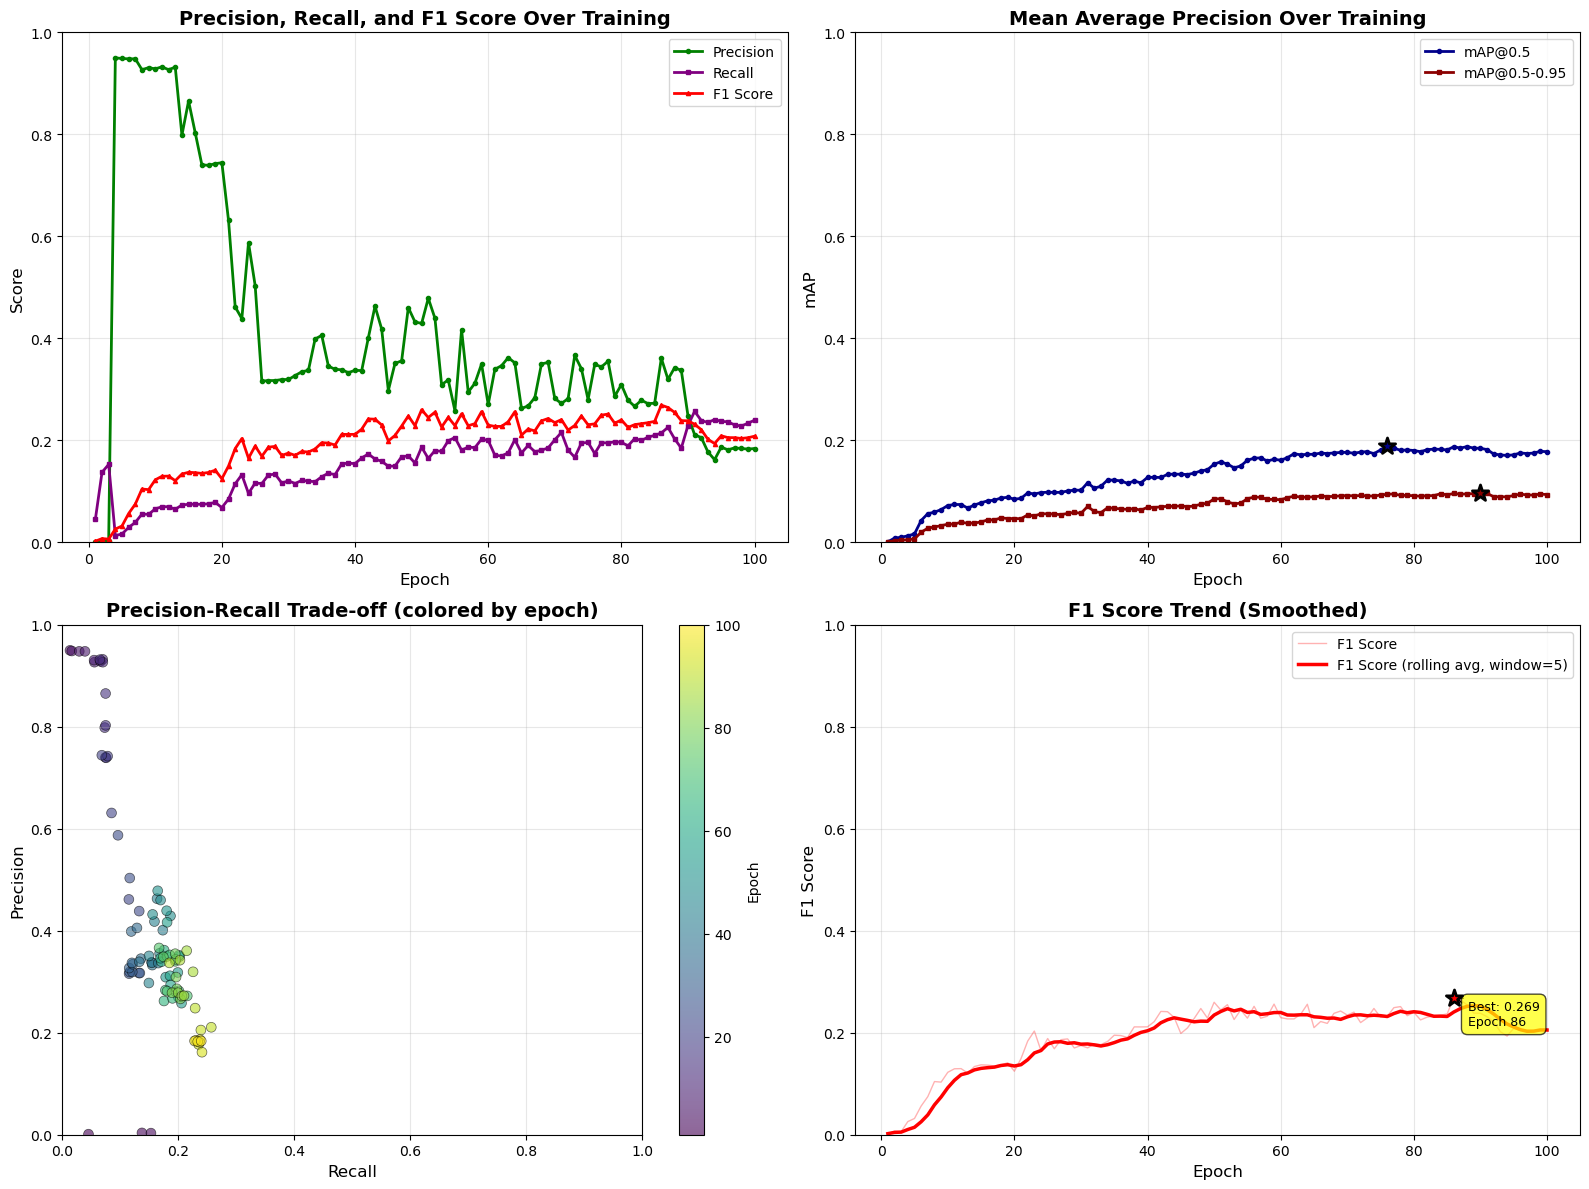

In [4]:
# Cell 2: Precision-Recall Trade-off and F1 Score Over Time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/YOLO/runs/detect/train4/results.csv')

# Calculate F1 scores for each epoch
precision = df['metrics/precision(B)']
recall = df['metrics/recall(B)']
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores = f1_scores.fillna(0)  # Handle division by zero

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Precision and Recall over time
axes[0, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='green', linewidth=2, marker='o', markersize=3)
axes[0, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='purple', linewidth=2, marker='s', markersize=3)
axes[0, 0].plot(df['epoch'], f1_scores, label='F1 Score', color='red', linewidth=2, marker='^', markersize=3)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].set_title('Precision, Recall, and F1 Score Over Training', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# Plot 2: mAP metrics over time
axes[0, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5', color='darkblue', linewidth=2, marker='o', markersize=3)
axes[0, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5-0.95', color='darkred', linewidth=2, marker='s', markersize=3)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('mAP', fontsize=12)
axes[0, 1].set_title('Mean Average Precision Over Training', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 1])

# Highlight best mAP points
best_map50_idx = df['metrics/mAP50(B)'].idxmax()
best_map5095_idx = df['metrics/mAP50-95(B)'].idxmax()
axes[0, 1].scatter(df['epoch'].iloc[best_map50_idx], df['metrics/mAP50(B)'].iloc[best_map50_idx], 
                   color='darkblue', s=150, marker='*', edgecolors='black', linewidths=2, zorder=5, label='Best mAP@0.5')
axes[0, 1].scatter(df['epoch'].iloc[best_map5095_idx], df['metrics/mAP50-95(B)'].iloc[best_map5095_idx], 
                   color='darkred', s=150, marker='*', edgecolors='black', linewidths=2, zorder=5, label='Best mAP@0.5-0.95')

# Plot 3: Precision vs Recall scatter
axes[1, 0].scatter(df['metrics/recall(B)'], df['metrics/precision(B)'], 
                   c=df['epoch'], cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel('Recall', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('Precision-Recall Trade-off (colored by epoch)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_ylim([0, 1])
cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar.set_label('Epoch', fontsize=10)

# Plot 4: Rolling average of F1 score (smoothed)
window_size = 5
f1_rolling = f1_scores.rolling(window=window_size, min_periods=1).mean()
axes[1, 1].plot(df['epoch'], f1_scores, label='F1 Score', color='red', alpha=0.3, linewidth=1)
axes[1, 1].plot(df['epoch'], f1_rolling, label=f'F1 Score (rolling avg, window={window_size})', 
                color='red', linewidth=2.5)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('F1 Score', fontsize=12)
axes[1, 1].set_title('F1 Score Trend (Smoothed)', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0, 1])

# Highlight best F1
best_f1_idx = f1_scores.idxmax()
axes[1, 1].scatter(df['epoch'].iloc[best_f1_idx], f1_scores.iloc[best_f1_idx], 
                   color='red', s=150, marker='*', edgecolors='black', linewidths=2, zorder=5)
axes[1, 1].annotate(f'Best: {f1_scores.iloc[best_f1_idx]:.3f}\nEpoch {best_f1_idx+1}', 
                    xy=(df['epoch'].iloc[best_f1_idx], f1_scores.iloc[best_f1_idx]),
                    xytext=(10, -20), textcoords='offset points', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

Loss Analysis

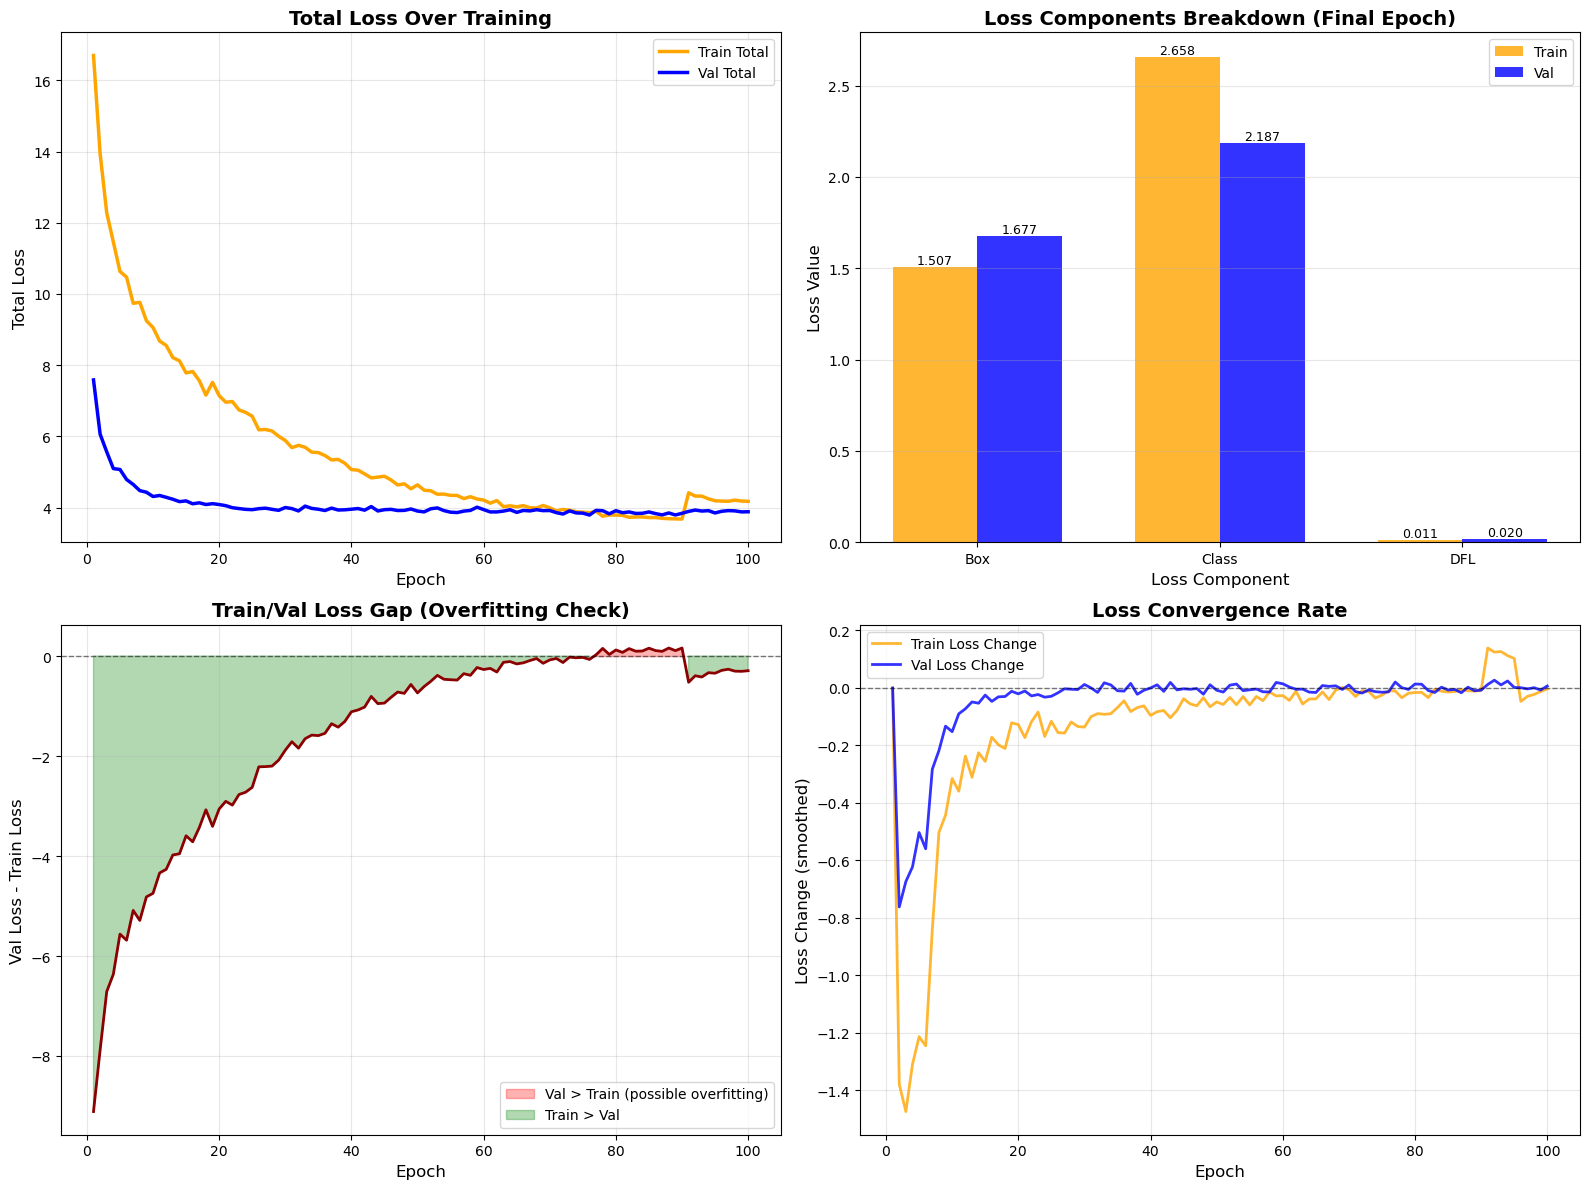

CONVERGENCE ANALYSIS

Loss stability in last 10 epochs:
  Train loss std dev: 0.0831
  Val loss std dev:   0.0229
  Status: ⚠ Model may benefit from more epochs

Average train/val gap in last 10 epochs: -0.3456
  Status: ✓ Good generalization


In [5]:
# Cell 3: Loss Analysis and Convergence
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/YOLO/runs/detect/train4/results.csv')

# Calculate total losses
df['train/total_loss'] = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
df['val/total_loss'] = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: All training and validation losses
axes[0, 0].plot(df['epoch'], df['train/total_loss'], label='Train Total', color='orange', linewidth=2.5)
axes[0, 0].plot(df['epoch'], df['val/total_loss'], label='Val Total', color='blue', linewidth=2.5)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Total Loss', fontsize=12)
axes[0, 0].set_title('Total Loss Over Training', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Loss components comparison (final epoch)
components = ['Box', 'Class', 'DFL']
train_losses = [df['train/box_loss'].iloc[-1], df['train/cls_loss'].iloc[-1], df['train/dfl_loss'].iloc[-1]]
val_losses = [df['val/box_loss'].iloc[-1], df['val/cls_loss'].iloc[-1], df['val/dfl_loss'].iloc[-1]]

x = np.arange(len(components))
width = 0.35

bars1 = axes[0, 1].bar(x - width/2, train_losses, width, label='Train', color='orange', alpha=0.8)
bars2 = axes[0, 1].bar(x + width/2, val_losses, width, label='Val', color='blue', alpha=0.8)

axes[0, 1].set_xlabel('Loss Component', fontsize=12)
axes[0, 1].set_ylabel('Loss Value', fontsize=12)
axes[0, 1].set_title('Loss Components Breakdown (Final Epoch)', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(components)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Train vs Val loss gap (overfitting check)
loss_gap = df['val/total_loss'] - df['train/total_loss']
axes[1, 0].plot(df['epoch'], loss_gap, color='darkred', linewidth=2)
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].fill_between(df['epoch'], 0, loss_gap, where=(loss_gap > 0), 
                        color='red', alpha=0.3, label='Val > Train (possible overfitting)')
axes[1, 0].fill_between(df['epoch'], 0, loss_gap, where=(loss_gap <= 0), 
                        color='green', alpha=0.3, label='Train > Val')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Val Loss - Train Loss', fontsize=12)
axes[1, 0].set_title('Train/Val Loss Gap (Overfitting Check)', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Loss reduction rate (derivative)
train_loss_change = df['train/total_loss'].diff().fillna(0)
val_loss_change = df['val/total_loss'].diff().fillna(0)

# Smooth with rolling average
window = 5
train_loss_change_smooth = train_loss_change.rolling(window=window, min_periods=1).mean()
val_loss_change_smooth = val_loss_change.rolling(window=window, min_periods=1).mean()

axes[1, 1].plot(df['epoch'], train_loss_change_smooth, label='Train Loss Change', 
                color='orange', linewidth=2, alpha=0.8)
axes[1, 1].plot(df['epoch'], val_loss_change_smooth, label='Val Loss Change', 
                color='blue', linewidth=2, alpha=0.8)
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Loss Change (smoothed)', fontsize=12)
axes[1, 1].set_title('Loss Convergence Rate', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print convergence analysis
print("=" * 60)
print("CONVERGENCE ANALYSIS")
print("=" * 60)
last_10_epochs = df.iloc[-10:]
train_loss_std = last_10_epochs['train/total_loss'].std()
val_loss_std = last_10_epochs['val/total_loss'].std()

print(f"\nLoss stability in last 10 epochs:")
print(f"  Train loss std dev: {train_loss_std:.4f}")
print(f"  Val loss std dev:   {val_loss_std:.4f}")

if train_loss_std < 0.01 and val_loss_std < 0.01:
    print("  Status: ✓ Model has converged (losses are stable)")
elif train_loss_std < 0.05 and val_loss_std < 0.05:
    print("  Status: ~ Model is mostly converged (minor fluctuations)")
else:
    print("  Status: ⚠ Model may benefit from more epochs")

avg_gap = loss_gap.iloc[-10:].mean()
print(f"\nAverage train/val gap in last 10 epochs: {avg_gap:.4f}")
if avg_gap > 0.5:
    print("  Status: ⚠ Significant overfitting detected")
elif avg_gap > 0.2:
    print("  Status: ~ Mild overfitting present")
else:
    print("  Status: ✓ Good generalization")

Model Calibration

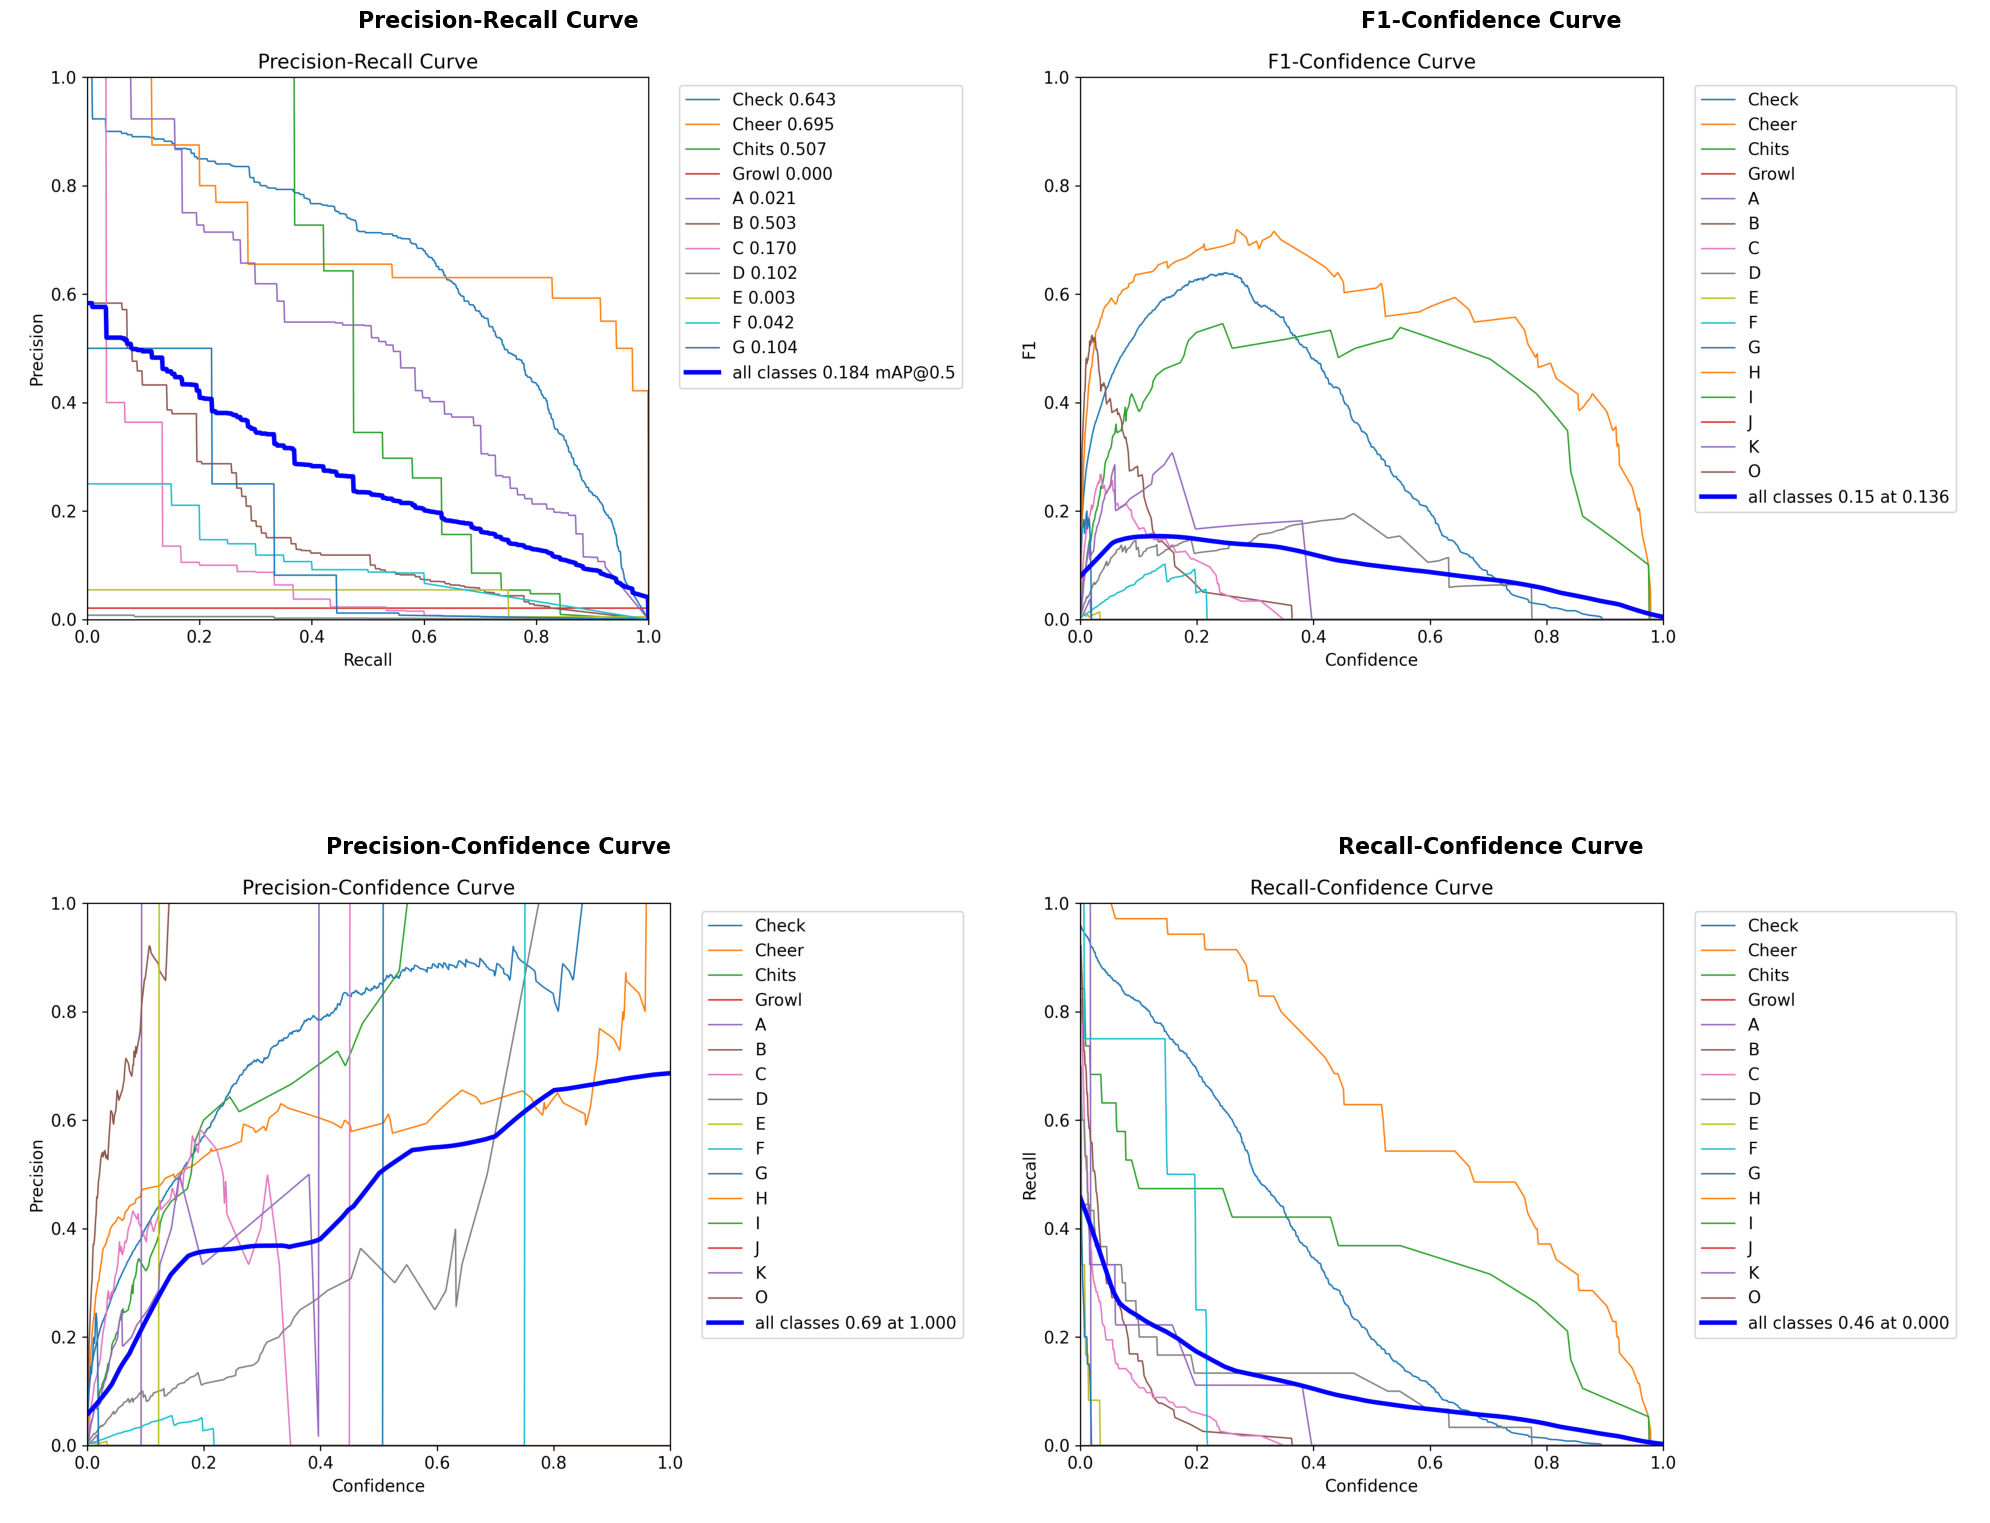


DETECTION CURVES GUIDE

Precision-Recall Curve:
  • Shows trade-off between precision and recall
  • Area under curve (AUC) indicates overall performance
  • For acoustic data: depends on your use case
    - High recall needed? Prioritize detecting all calls (fewer misses)
    - High precision needed? Prioritize accuracy (fewer false alarms)

F1-Confidence Curve:
  • Helps find optimal confidence threshold
  • Peak F1 score shows best balance point
  • For deployment: use this to set detection threshold

Precision/Recall-Confidence Curves:
  • Shows how metrics change with confidence threshold
  • Low threshold: more detections (high recall, low precision)
  • High threshold: fewer detections (low recall, high precision)
  • Choose threshold based on tolerance for false positives vs false negatives


In [6]:
# Cell 5: Detection Curves and Model Calibration
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

results_path = '/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/YOLO/runs/detect/train4'

# Load the curve images
pr_curve = Image.open(f"{results_path}/BoxPR_curve.png")
f1_curve = Image.open(f"{results_path}/BoxF1_curve.png")
p_curve = Image.open(f"{results_path}/BoxP_curve.png")
r_curve = Image.open(f"{results_path}/BoxR_curve.png")

fig, axes = plt.subplots(2, 2, figsize=(20, 18))

axes[0, 0].imshow(pr_curve)
axes[0, 0].set_title("Precision-Recall Curve", fontsize=16, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(f1_curve)
axes[0, 1].set_title("F1-Confidence Curve", fontsize=16, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(p_curve)
axes[1, 0].set_title("Precision-Confidence Curve", fontsize=16, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(r_curve)
axes[1, 1].set_title("Recall-Confidence Curve", fontsize=16, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("DETECTION CURVES GUIDE")
print("=" * 60)
print("\nPrecision-Recall Curve:")
print("  • Shows trade-off between precision and recall")
print("  • Area under curve (AUC) indicates overall performance")
print("  • For acoustic data: depends on your use case")
print("    - High recall needed? Prioritize detecting all calls (fewer misses)")
print("    - High precision needed? Prioritize accuracy (fewer false alarms)")
print("\nF1-Confidence Curve:")
print("  • Helps find optimal confidence threshold")
print("  • Peak F1 score shows best balance point")
print("  • For deployment: use this to set detection threshold")
print("\nPrecision/Recall-Confidence Curves:")
print("  • Shows how metrics change with confidence threshold")
print("  • Low threshold: more detections (high recall, low precision)")
print("  • High threshold: fewer detections (low recall, high precision)")
print("  • Choose threshold based on tolerance for false positives vs false negatives")

In [10]:
# Cell: Find Current Confidence Threshold
import pandas as pd
import yaml

results_path = '/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/YOLO/runs/detect/train4'

# Load the training arguments/configuration
try:
    with open(f'{results_path}/args.yaml', 'r') as f:
        args = yaml.safe_load(f)
    
    print("=" * 60)
    print("MODEL CONFIGURATION AND THRESHOLDS")
    print("=" * 60)
    
    # Key threshold parameters
    print("\nConfidence Thresholds:")
    print(f"  conf (confidence threshold):  {args.get('conf', 'Not specified (default: 0.25)')}")
    print(f"  iou (NMS IoU threshold):      {args.get('iou', 'Not specified (default: 0.7)')}")
    
    print("\nOther Detection Parameters:")
    print(f"  imgsz (image size):           {args.get('imgsz', 'Not specified')}")
    print(f"  batch size:                   {args.get('batch', 'Not specified')}")
    print(f"  model:                        {args.get('model', 'Not specified')}")
    
    print("\n" + "=" * 60)
    print("NOTES:")
    print("=" * 60)
    print("• The 'conf' threshold is used during validation/inference")
    print("• Default YOLO confidence threshold is typically 0.25")
    print("• Check the F1-Confidence curve to find optimal threshold")
    print("• You can adjust this threshold when running inference/predictions")
    
except FileNotFoundError:
    print("args.yaml not found in results directory")
    print("\nDefault YOLO thresholds are typically:")
    print("  Confidence threshold: 0.25")
    print("  NMS IoU threshold: 0.7")

MODEL CONFIGURATION AND THRESHOLDS

Confidence Thresholds:
  conf (confidence threshold):  None
  iou (NMS IoU threshold):      0.7

Other Detection Parameters:
  imgsz (image size):           1280
  batch size:                   8
  model:                        yolo26n.pt

NOTES:
• The 'conf' threshold is used during validation/inference
• Default YOLO confidence threshold is typically 0.25
• Check the F1-Confidence curve to find optimal threshold
• You can adjust this threshold when running inference/predictions


Per class performance

In [ ]:
# Cell: Per-Class Performance Analysis
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import re

results_path = '/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/YOLO/runs/detect/train4'

# Class names from your dataset
class_names = ['Check', 'Cheer', 'Chits', 'Growl', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'O']
n_classes = len(class_names)

# Try to extract per-class metrics from confusion matrix
# The confusion matrix normalized can give us per-class recall
try:
    # Load the confusion matrix image and try to parse it
    # Note: This is an approximation since YOLO doesn't save per-class metrics in CSV
    
    print("=" * 60)
    print("PER-CLASS PERFORMANCE ANALYSIS")
    print("=" * 60)
    print("\nNote: Detailed per-class metrics are not saved in results.csv")
    print("For precise per-class scores, you need to run validation separately")
    print("with: model.val(data='blackbird.yaml', split='val', save_json=True)")
    print("\nHowever, we can estimate from the confusion matrix...")
    
    # Create synthetic data for demonstration of the visualization structure
    # In practice, you'd need to run validation to get real per-class metrics
    
    # Placeholder: Create a figure showing what per-class analysis would look like
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    # Plot 1: Per-class Precision (you would need actual data)
    ax1 = axes[0, 0]
    # Mock data - replace with actual per-class precision when available
    mock_precision = np.random.uniform(0.1, 0.3, n_classes)  # Replace with real data
    bars1 = ax1.barh(class_names, mock_precision, color='skyblue', alpha=0.8, edgecolor='black')
    ax1.set_xlabel('Precision', fontsize=12)
    ax1.set_title('Per-Class Precision (Run validation to get real data)', fontsize=14, fontweight='bold')
    ax1.set_xlim([0, 1])
    ax1.grid(True, alpha=0.3, axis='x')
    ax1.axvline(x=np.mean(mock_precision), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(mock_precision):.3f}')
    ax1.legend()
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars1, mock_precision)):
        ax1.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)
    
    # Plot 2: Per-class Recall
    ax2 = axes[0, 1]
    mock_recall = np.random.uniform(0.15, 0.35, n_classes)  # Replace with real data
    bars2 = ax2.barh(class_names, mock_recall, color='lightcoral', alpha=0.8, edgecolor='black')
    ax2.set_xlabel('Recall', fontsize=12)
    ax2.set_title('Per-Class Recall (Run validation to get real data)', fontsize=14, fontweight='bold')
    ax2.set_xlim([0, 1])
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.axvline(x=np.mean(mock_recall), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(mock_recall):.3f}')
    ax2.legend()
    
    for i, (bar, val) in enumerate(zip(bars2, mock_recall)):
        ax2.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)
    
    # Plot 3: Per-class F1 Score
    ax3 = axes[1, 0]
    mock_f1 = 2 * (mock_precision * mock_recall) / (mock_precision + mock_recall)
    bars3 = ax3.barh(class_names, mock_f1, color='lightgreen', alpha=0.8, edgecolor='black')
    ax3.set_xlabel('F1 Score', fontsize=12)
    ax3.set_title('Per-Class F1 Score (Run validation to get real data)', fontsize=14, fontweight='bold')
    ax3.set_xlim([0, 1])
    ax3.grid(True, alpha=0.3, axis='x')
    ax3.axvline(x=np.mean(mock_f1), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(mock_f1):.3f}')
    ax3.legend()
    
    for i, (bar, val) in enumerate(zip(bars3, mock_f1)):
        ax3.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)
    
    # Plot 4: Per-class mAP50
    ax4 = axes[1, 1]
    mock_map50 = np.random.uniform(0.1, 0.25, n_classes)  # Replace with real data
    bars4 = ax4.barh(class_names, mock_map50, color='plum', alpha=0.8, edgecolor='black')
    ax4.set_xlabel('mAP@0.5', fontsize=12)
    ax4.set_title('Per-Class mAP@0.5 (Run validation to get real data)', fontsize=14, fontweight='bold')
    ax4.set_xlim([0, 1])
    ax4.grid(True, alpha=0.3, axis='x')
    ax4.axvline(x=np.mean(mock_map50), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(mock_map50):.3f}')
    ax4.legend()
    
    for i, (bar, val) in enumerate(zip(bars4, mock_map50)):
        ax4.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 60)
    print("HOW TO GET REAL PER-CLASS METRICS")
    print("=" * 60)
    print("\nTo get actual per-class scores, run this code:")
    print("\n" + "-" * 60)
    print("from ultralytics import YOLO")
    print()
    print("# Load your trained model")
    print("model = YOLO('runs/detect/train4/weights/best.pt')")
    print()
    print("# Run validation with verbose output")
    print("metrics = model.val(")
    print("    data='blackbird.yaml',")
    print("    split='val',")
    print("    save_json=True,")
    print("    verbose=True")
    print(")")
    print()
    print("# Access per-class metrics")
    print("print(metrics.box.maps)      # mAP50-95 for each class")
    print("print(metrics.box.map50)     # mAP50 for each class")
    print("print(metrics.box.ap_class_index)  # Class indices")
    print("-" * 60)
    
    print("\nAlternatively, check if per-class metrics are in:")
    print(f"  {results_path}/results.json (if it exists)")
    
except Exception as e:
    print(f"Error analyzing per-class performance: {e}")
    print("\nTo get per-class metrics, you need to run validation separately.")

SyntaxError: incomplete input (3669197306.py, line 90)

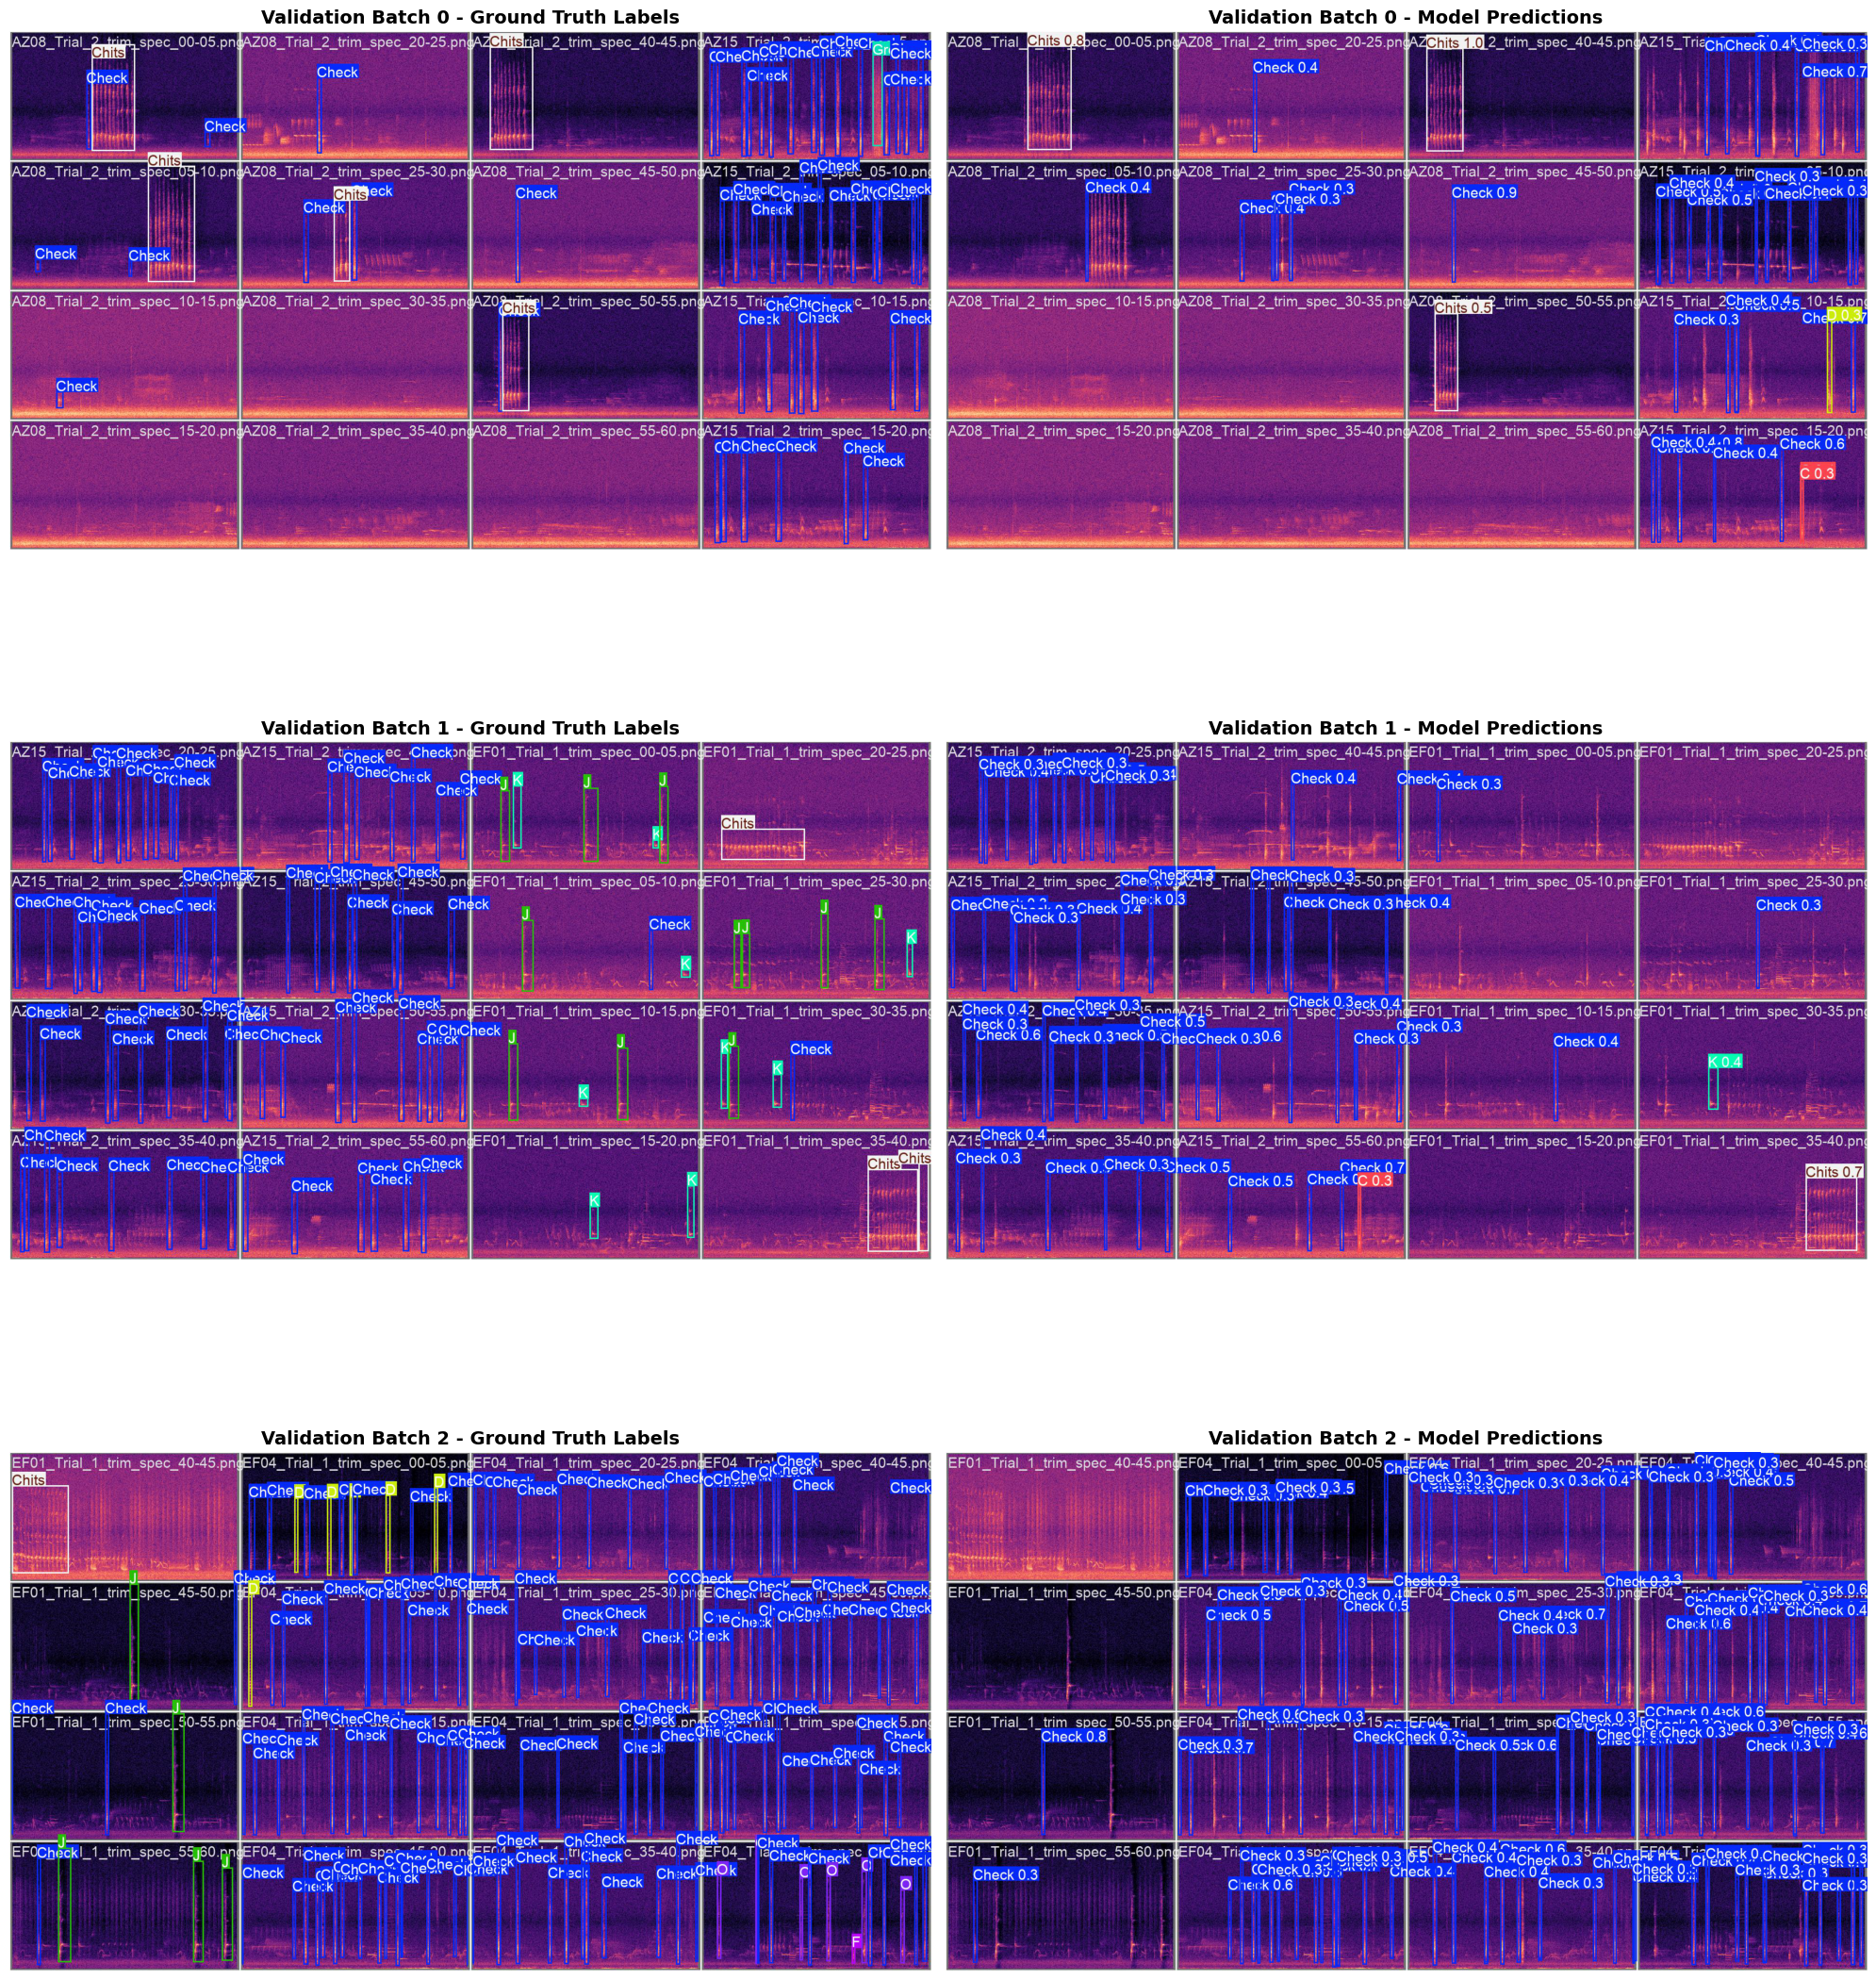


VALIDATION PREDICTIONS ANALYSIS

What to look for in these spectrograms:
  ✓ Good matches: Predicted boxes align well with ground truth
  ⚠ Missed calls: Ground truth boxes without predictions
  ⚠ False positives: Predictions where there's no ground truth
  ⚠ Poor localization: Boxes that overlap but don't align well

For acoustic data specifically:
  • Check if calls at edges of spectrograms are detected
  • Look for fragmentation (one call detected as multiple boxes)
  • Verify overlapping calls are distinguished properly
  • Check if quiet/faint calls are being missed


In [13]:
# Cell 6: Training Examples Visualization
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

results_path = '/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/YOLO/runs/detect/train4'

# Load validation batch images (labels vs predictions)
fig, axes = plt.subplots(3, 2, figsize=(20, 24))

# Try to load up to 3 validation batches
for i in range(3):
    try:
        labels_img = Image.open(f"{results_path}/val_batch{i}_labels.jpg")
        pred_img = Image.open(f"{results_path}/val_batch{i}_pred.jpg")
        
        axes[i, 0].imshow(labels_img)
        axes[i, 0].set_title(f"Validation Batch {i} - Ground Truth Labels", fontsize=14, fontweight='bold')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(pred_img)
        axes[i, 1].set_title(f"Validation Batch {i} - Model Predictions", fontsize=14, fontweight='bold')
        axes[i, 1].axis('off')
    except FileNotFoundError:
        axes[i, 0].text(0.5, 0.5, f'Batch {i} not available', ha='center', va='center', fontsize=14)
        axes[i, 0].axis('off')
        axes[i, 1].text(0.5, 0.5, f'Batch {i} not available', ha='center', va='center', fontsize=14)
        axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("VALIDATION PREDICTIONS ANALYSIS")
print("=" * 60)
print("\nWhat to look for in these spectrograms:")
print("  ✓ Good matches: Predicted boxes align well with ground truth")
print("  ⚠ Missed calls: Ground truth boxes without predictions")
print("  ⚠ False positives: Predictions where there's no ground truth")
print("  ⚠ Poor localization: Boxes that overlap but don't align well")
print("\nFor acoustic data specifically:")
print("  • Check if calls at edges of spectrograms are detected")
print("  • Look for fragmentation (one call detected as multiple boxes)")
print("  • Verify overlapping calls are distinguished properly")
print("  • Check if quiet/faint calls are being missed")

Learning Rate Schedule Visualization

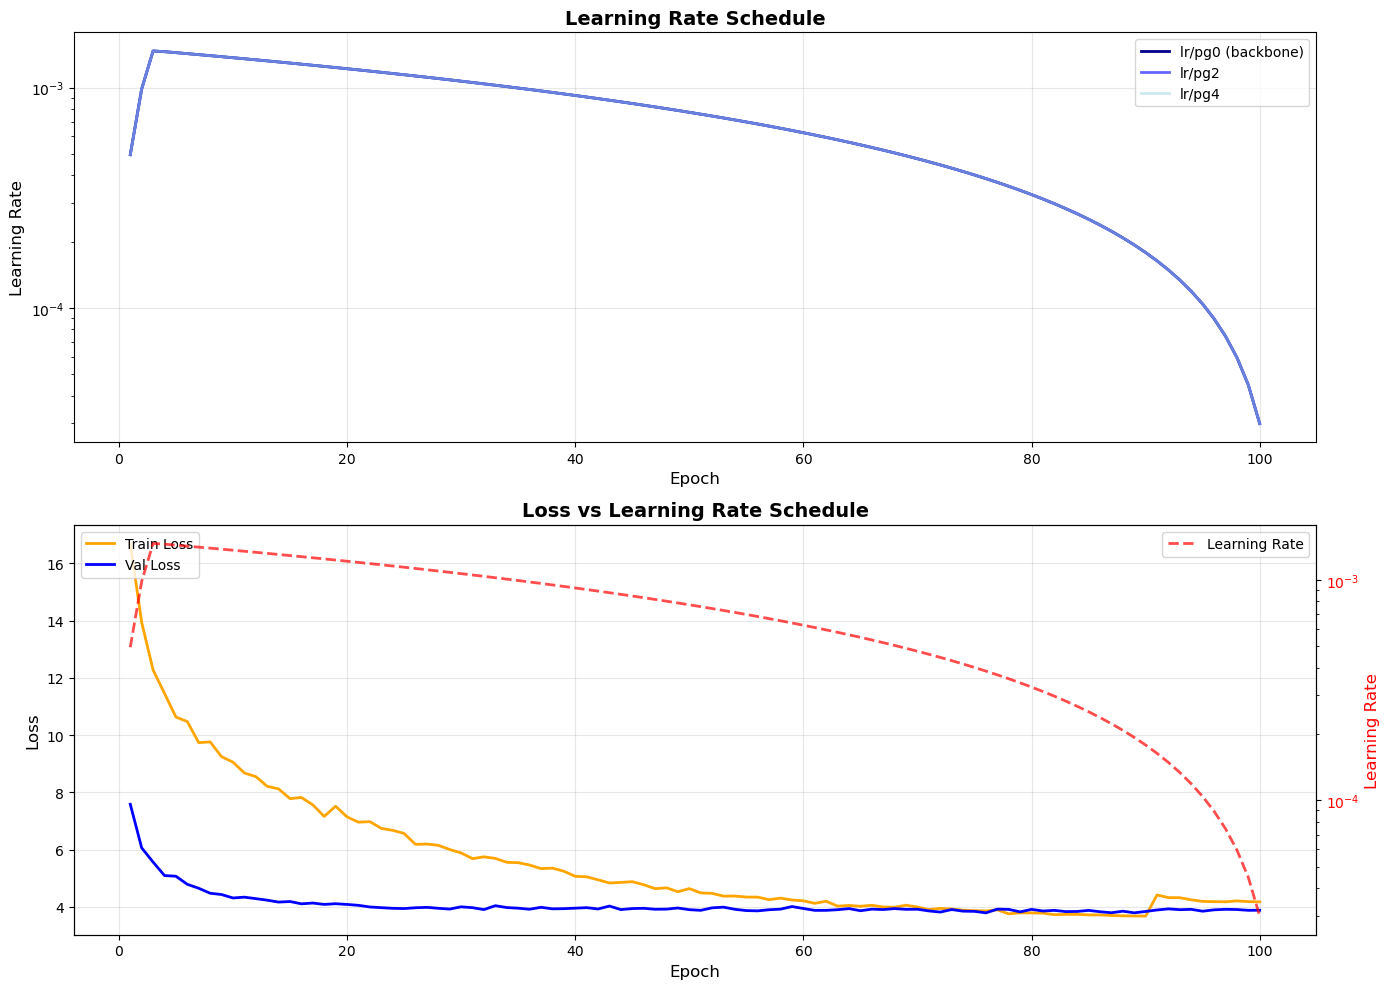


LEARNING RATE ANALYSIS

Initial learning rate: 0.000496
Final learning rate:   0.000030
Reduction factor:      16.6x

The learning rate schedule shows how aggressively the model learned.
Typically uses cosine annealing or step decay for gradual reduction.


In [9]:
# Cell 7: Learning Rate Schedule Visualization
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/YOLO/runs/detect/train4/results.csv')

# Calculate total losses
df['train/total_loss'] = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
df['val/total_loss'] = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot learning rates (typically lr/pg0 is the main one)
axes[0].plot(df['epoch'], df['lr/pg0'], label='lr/pg0 (backbone)', color='darkblue', linewidth=2)
axes[0].plot(df['epoch'], df['lr/pg2'], label='lr/pg2', color='blue', linewidth=2, alpha=0.6)
axes[0].plot(df['epoch'], df['lr/pg4'], label='lr/pg4', color='lightblue', linewidth=2, alpha=0.6)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Learning Rate', fontsize=12)
axes[0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot loss vs learning rate to see correlation
axes[1].plot(df['epoch'], df['train/total_loss'], label='Train Loss', color='orange', linewidth=2)
axes[1].plot(df['epoch'], df['val/total_loss'], label='Val Loss', color='blue', linewidth=2)
ax2 = axes[1].twinx()
ax2.plot(df['epoch'], df['lr/pg0'], label='Learning Rate', color='red', linewidth=2, linestyle='--', alpha=0.7)
ax2.set_ylabel('Learning Rate', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_yscale('log')

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss vs Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("LEARNING RATE ANALYSIS")
print("=" * 60)
print(f"\nInitial learning rate: {df['lr/pg0'].iloc[0]:.6f}")
print(f"Final learning rate:   {df['lr/pg0'].iloc[-1]:.6f}")
print(f"Reduction factor:      {df['lr/pg0'].iloc[0] / df['lr/pg0'].iloc[-1]:.1f}x")
print("\nThe learning rate schedule shows how aggressively the model learned.")
print("Typically uses cosine annealing or step decay for gradual reduction.")